[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brenoprato/calculo-numerico/blob/main/atividades/atv_1/resolucao.ipynb)

# Atividade Prática I - Cálculo Numérico
**Professora:** Raquel J. Lobosco

---
**Nomes dos integrantes:**

Breno Porto Pinheiro do Prado | 185196

Guilherme Bento Ramos | 185226

**Divisão das tarefas:** Realizamos cada atividade junto, intercalando quem escrevia o codigo e quem comentava.

**Obs:** Para algumas imagens/gifs é necessário abrir o colab para vizualizar

---

## 1. Fórmulas e preparação do ambiente
- **Erro Absoluto ($E_a$):** $E_a = |x - \tilde{x}|$
- **Erro Relativo ($E_r$):** $E_r = \frac{|x - \tilde{x}|}{|x|}$
- **Erro Percentual ($E_{\%}$):** $E_{\%} = 100 \cdot E_r$



In [35]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import imageio
import os
from IPython.display import Image, display

def erro_absoluto(x, x_aprox):
    '''
    Calcula o erro absoluto dado um valor de referência x e uma aproximação x_aprox.
    Fórmula: Ea = |x - x_aprox|
    '''
    return np.abs(x - x_aprox)

def erro_relativo(x, x_aprox):
    '''
    Calcula o erro relativo dado um valor de referência x e uma aproximação x_aprox.
    Fórmula: Er = |x - x_aprox| / |x|
    '''
    return np.abs(x - x_aprox) / np.abs(x)

def erro_percentual(x, x_aprox):
    '''
    Calcula o erro percentual.
    Fórmula: E% = 100 * Er
    '''
    return 100 * erro_relativo(x, x_aprox)

def truncar(x, n):
    '''
    Trunca o valor x para n casas decimais.
    A função multiplica o número por 10^n, descarta a parte fracionária (com np.trunc)
    e depois divide por 10^n.
    Dessa forma, os algarismos posteriores à casa 'n' são simplesmente eliminados.
    '''
    fator = 10**n
    return np.trunc(fator * x) / fator

# Ajuste visual para tabelas Pandas
pd.set_option('display.float_format', lambda x: '%.10g' % x)



---
## Parte A – Truncamento e arredondamento

Nesta etapa avaliamos o erro introduzido ao limitarmos o número de casas decimais de três valores distintos ($x_1, x_2, x_3$). Calculamos as aproximações por truncamento e arredondamento e quantificamos os erros gerados.



,Valor (x),Casas (n),Método,Aproximação,Ea,Er,E%
0,3.14159265,0,Truncamento,3,0.14159265,0.04507034036,4.507034036
1,3.14159265,0,Arredondamento,3,0.14159265,0.04507034036,4.507034036
2,3.14159265,1,Truncamento,3.1,0.04159265,0.0132393517,1.32393517
3,3.14159265,1,Arredondamento,3.1,0.04159265,0.0132393517,1.32393517
4,3.14159265,2,Truncamento,3.14,0.00159265,0.0005069562408,0.05069562408
5,3.14159265,2,Arredondamento,3.14,0.00159265,0.0005069562408,0.05069562408
6,3.14159265,3,Truncamento,3.141,0.00059265,0.0001886463543,0.01886463543
7,3.14159265,3,Arredondamento,3.142,0.00040735,0.0001296635323,0.01296635323
8,3.14159265,4,Truncamento,3.1415,9.265e-05,2.949141099e-05,0.002949141099
9,3.14159265,4,Arredondamento,3.1416,7.35e-06,2.339577666e-06,0.0002339577666


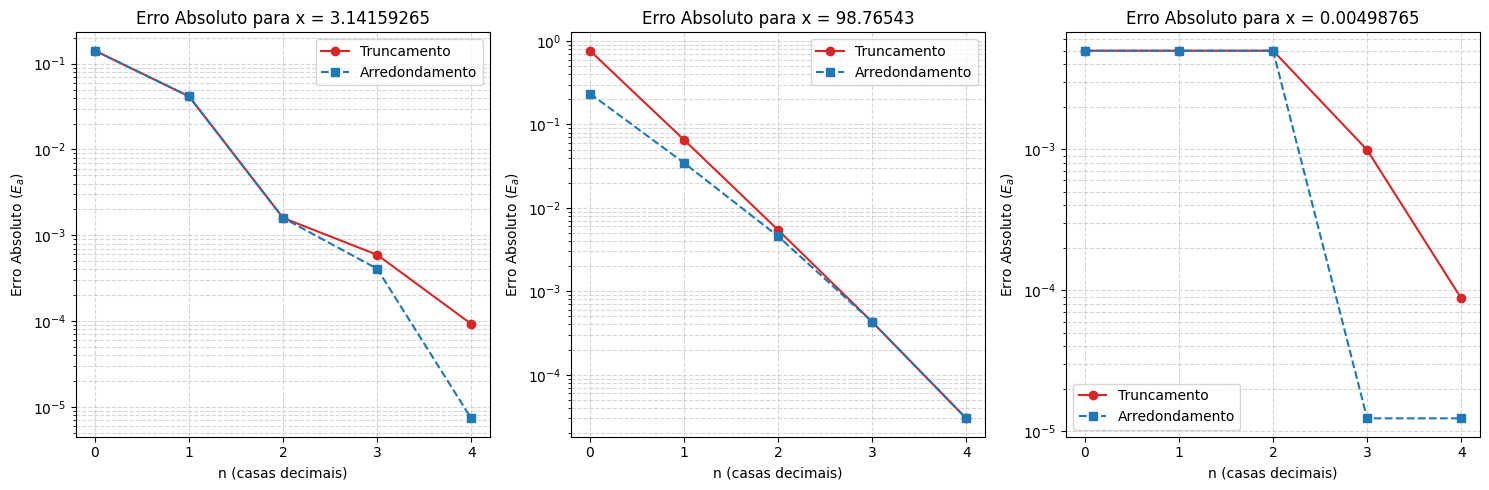

In [36]:
# Valores fornecidos
x_vals = [3.14159265, 98.76543, 0.00498765]
casas = [0, 1, 2, 3, 4]

resultados_A = []

for x in x_vals:
    for n in casas:
        # 1. Cálculo por Truncamento
        x_trunc = truncar(x, n)
        ea_trunc = erro_absoluto(x, x_trunc)
        er_trunc = erro_relativo(x, x_trunc)
        ep_trunc = erro_percentual(x, x_trunc)

        # 2. Cálculo por Arredondamento (Python usa round to nearest even, que descarta adequadamente)
        x_arred = round(x, n)
        ea_arred = erro_absoluto(x, x_arred)
        er_arred = erro_relativo(x, x_arred)
        ep_arred = erro_percentual(x, x_arred)

        # Armazenando resultados
        resultados_A.append({
            'Valor (x)': x, 'Casas (n)': n, 'Método': 'Truncamento',
            'Aproximação': x_trunc, 'Ea': ea_trunc, 'Er': er_trunc, 'E%': ep_trunc
        })
        resultados_A.append({
            'Valor (x)': x, 'Casas (n)': n, 'Método': 'Arredondamento',
            'Aproximação': x_arred, 'Ea': ea_arred, 'Er': er_arred, 'E%': ep_arred
        })

# 3. Tabela Organizada
df_A = pd.DataFrame(resultados_A)
display(df_A)

# 4. Gráfico em escala logarítmica de Ea em função de n
plt.figure(figsize=(15, 5))
for i, x in enumerate(x_vals):
    plt.subplot(1, 3, i+1)
    df_x = df_A[df_A['Valor (x)'] == x]

    trunc_data = df_x[df_x['Método'] == 'Truncamento']
    arred_data = df_x[df_x['Método'] == 'Arredondamento']

    plt.plot(trunc_data['Casas (n)'], trunc_data['Ea'], 'o-', label='Truncamento', color='#d62728')
    plt.plot(arred_data['Casas (n)'], arred_data['Ea'], 's--', label='Arredondamento', color='#1f77b4')

    plt.yscale('log')
    plt.title(f'Erro Absoluto para x = {x}')
    plt.xlabel('n (casas decimais)')
    plt.ylabel('Erro Absoluto ($E_a$)')
    plt.xticks(casas)
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()



### 5. Resposta: Arredondar sempre gera erro menor ou igual ao truncamento?

**Sim, arredondar sempre gera um erro menor ou igual ao truncamento.**
* **Justificativa teórica:** O truncamento simplesmente elimina os algarismos, o que significa que o erro absoluto máximo é limitado por $10^{-n}$. Já o arredondamento seleciona o número com $n$ casas decimais que está mais próximo do valor original, limitando o erro absoluto a $0,5 \times 10^{-n}$.
* **Evidência nos resultados:** Observando a tabela e os gráficos, vemos que em nenhum caso a curva de arredondamento ficou acima da curva de truncamento. Quando o algarismo seguinte à casa $n$ é menor que 5, truncar e arredondar produzem o exato mesmo número, empatando o erro ($E_{a \text{(arred)}} = E_{a \text{(trunc)}}$). Quando o algarismo é 5 ou maior, o arredondamento escolhe o limite superior, garantindo um erro menor que o corte bruto do truncamento.



---
## Parte B – Medidas de pressão arterial

Nesta seção, analisamos como a precisão de um conjunto de dados afeta a sua representação estatística (média, desvio-padrão, amplitude).

In [37]:
medidas_originais = np.array([121.7, 120.4, 122.1, 119.8, 121.2, 120.9, 122.4, 121.0, 120.2, 121.5])
media_ref = np.mean(medidas_originais)

# B.1 Representação das Medidas
# Construção das 3 séries solicitadas
series = {
    '1. Originais': medidas_originais,
    '2. Arredondados': np.round(medidas_originais),
    '3. Truncados': np.trunc(medidas_originais)
}

# Cálculo das estatísticas para cada série
stats = []
for nome, s in series.items():
    stats.append({
        'Série': nome,
        'Média (mmHg)': np.mean(s),
        'Mínimo (mmHg)': np.min(s),
        'Máximo (mmHg)': np.max(s),
        'Amplitude (mmHg)': np.max(s) - np.min(s),
        'Desvio-padrão (mmHg)': np.std(s, ddof=1)
    })

print("ESTATÍSTICAS DAS SÉRIES:")
df_stats = pd.DataFrame(stats)
display(df_stats)

# Erros da média aproximada em relação à média de referência
erros_medias = []
for nome in ['2. Arredondados', '3. Truncados']:
    media_aprox = np.mean(series[nome])
    erros_medias.append({
        'Série': nome.split('. ')[1],
        'Erro Absoluto (Ea)': erro_absoluto(media_ref, media_aprox),
        'Erro Relativo (Er)': erro_relativo(media_ref, media_aprox),
        'Erro Percentual (E%)': erro_percentual(media_ref, media_aprox)
    })

print("\nERROS EM RELAÇÃO À MÉDIA DE REFERÊNCIA:")
df_erros_medias = pd.DataFrame(erros_medias)
display(df_erros_medias)

ESTATÍSTICAS DAS SÉRIES:


,Série,Média (mmHg),Mínimo (mmHg),Máximo (mmHg),Amplitude (mmHg),Desvio-padrão (mmHg)
0,1. Originais,121.12,119.8,122.4,2.6,0.8337332374
1,2. Arredondados,121.1,120,122,2,0.8755950358
2,3. Truncados,120.7,119,122,3,0.9486832981



ERROS EM RELAÇÃO À MÉDIA DE REFERÊNCIA:


,Série,Erro Absoluto (Ea),Erro Relativo (Er),Erro Percentual (E%)
0,Arredondados,0.02,0.0001651254954,0.01651254954
1,Truncados,0.42,0.003467635403,0.3467635403


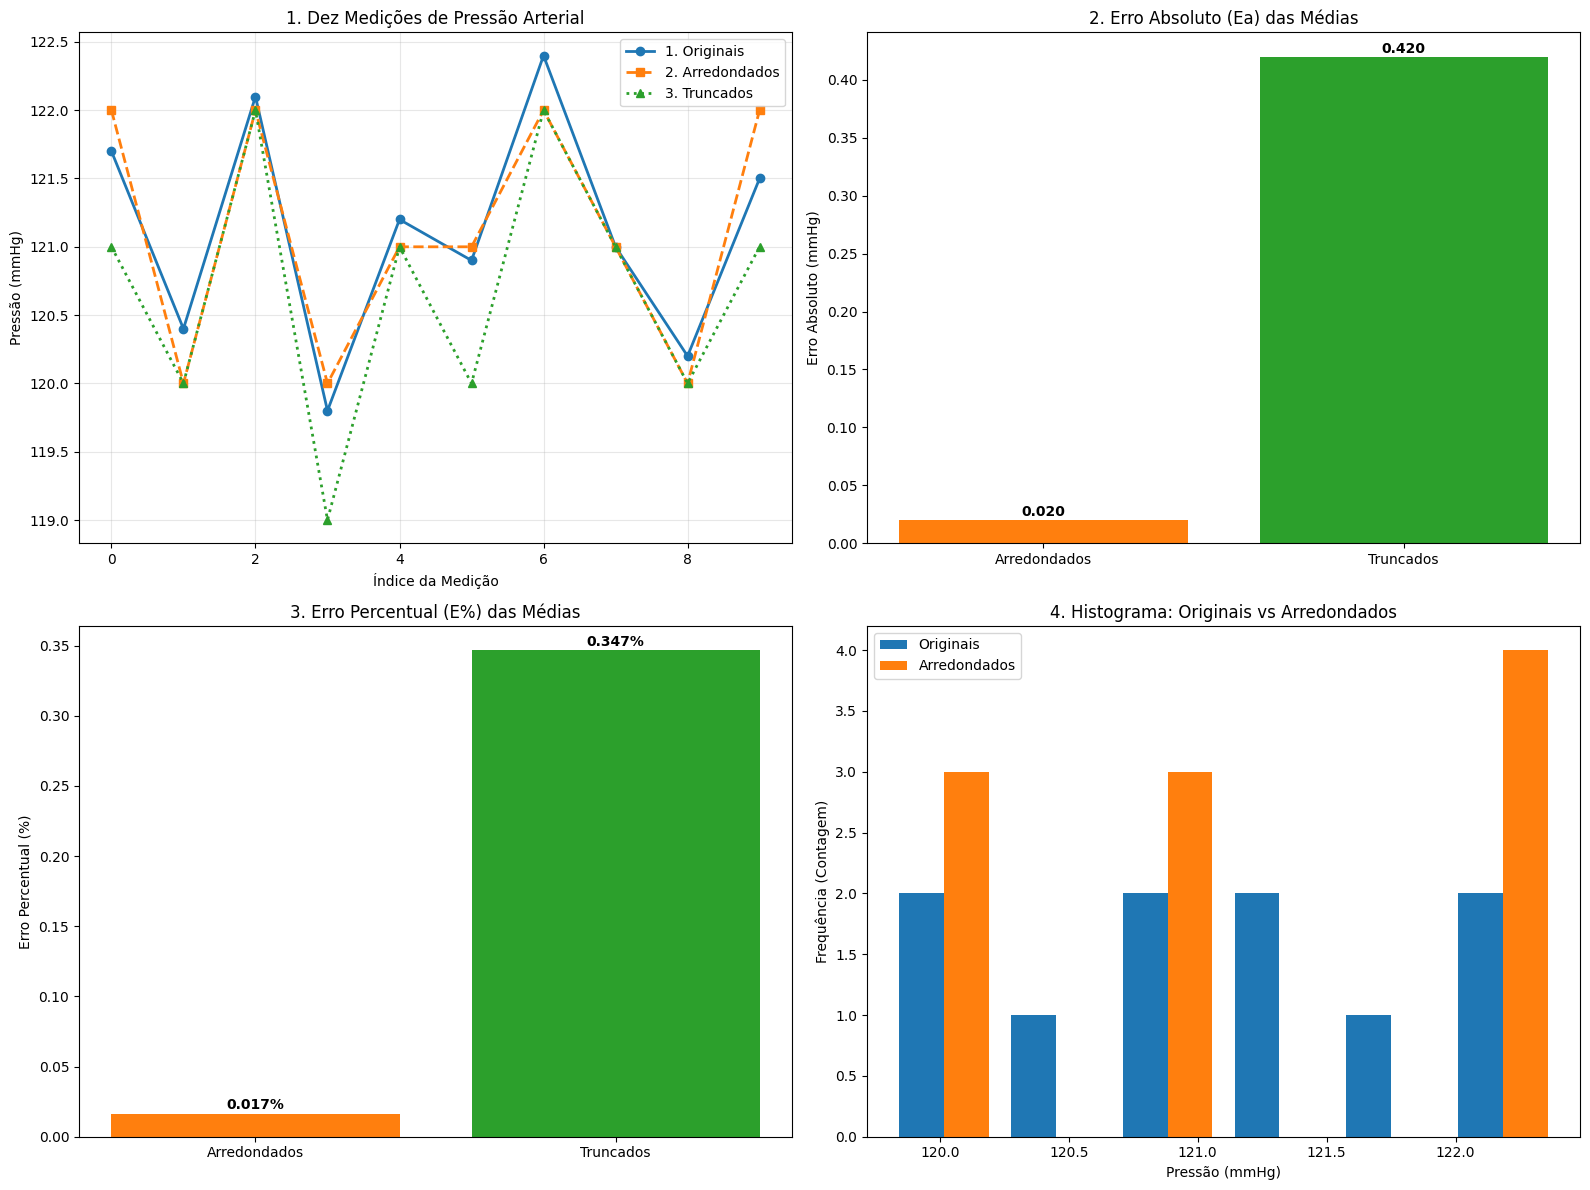

In [38]:
# B.2 Gráficos Obrigatórios
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# 1. Gráfico das dez medições (3 séries)
for nome, s in series.items():
    fmt = 'o-' if 'Originais' in nome else 's--' if 'Arredondados' in nome else '^:'
    axs[0, 0].plot(s, fmt, label=nome, linewidth=2)
axs[0, 0].set_title('1. Dez Medições de Pressão Arterial')
axs[0, 0].set_xlabel('Índice da Medição')
axs[0, 0].set_ylabel('Pressão (mmHg)')
axs[0, 0].legend()
axs[0, 0].grid(True, alpha=0.3)

# 2. Gráfico de barras dos erros absolutos das médias
bars2 = axs[0, 1].bar(df_erros_medias['Série'], df_erros_medias['Erro Absoluto (Ea)'], color=['#ff7f0e', '#2ca02c'])
axs[0, 1].set_title('2. Erro Absoluto (Ea) das Médias')
axs[0, 1].set_ylabel('Erro Absoluto (mmHg)')
for bar in bars2:
    yval = bar.get_height()
    axs[0, 1].text(bar.get_x() + bar.get_width()/2, yval + 0.001, f'{yval:.3f}', ha='center', va='bottom', weight='bold')

# 3. Gráfico de barras dos erros percentuais das médias
bars3 = axs[1, 0].bar(df_erros_medias['Série'], df_erros_medias['Erro Percentual (E%)'], color=['#ff7f0e', '#2ca02c'])
axs[1, 0].set_title('3. Erro Percentual (E%) das Médias')
axs[1, 0].set_ylabel('Erro Percentual (%)')
for bar in bars3:
    yval = bar.get_height()
    axs[1, 0].text(bar.get_x() + bar.get_width()/2, yval + 0.001, f'{yval:.3f}%', ha='center', va='bottom', weight='bold')

# 4. Histograma dos dados originais e dos inteiros arredondados
axs[1, 1].hist([series['1. Originais'], series['2. Arredondados']], bins=6, color=['#1f77b4', '#ff7f0e'], label=['Originais', 'Arredondados'])
axs[1, 1].set_title('4. Histograma: Originais vs Arredondados')
axs[1, 1].set_xlabel('Pressão (mmHg)')
axs[1, 1].set_ylabel('Frequência (Contagem)')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

### Explicação (Parte B)
A representação inteira **não é suficiente** para preservar perfeitamente a média e a variabilidade nesta pequena amostra.
Quando arredondamos (ou truncamos) os dados, ocorre uma perda severa de resolução (as sutilezas e frações da pressão são achatadas). A média sofreu um pequeno desvio (erro absoluto visualizado acima) e, mais criticamente, a variabilidade, medida pelo Desvio-Padrão Amostral e pela Amplitude, mudou. O histograma reflete isso perfeitamente: os dados originais estavam espalhados suavemente, enquanto os dados arredondados sofrem *aliasing* (aglomeram-se em pacotes discretos de valores exatos). Em amostras pequenas, essa redução da resolução introduz vieses não desprezíveis.



---
## Parte C – Vazão em um tubo de pequeno diâmetro

Nesta etapa avaliaremos a propagação de erro em equações não lineares (produto e potência). A equação de Hagen-Poiseuille modela a vazão ($Q$):
$$ Q = \frac{\pi r^4 \Delta p}{8 \mu L} $$



In [39]:
# Valores nominais (SI)
r_ref = 0.80e-3    # m (0,80 mm)
L_ref = 0.20       # m
mu_ref = 3.5e-3    # Pa s
dp_ref = 1200      # Pa

def hagen_poiseuille(r, L, mu, dp):
    return (np.pi * (r**4) * dp) / (8 * mu * L)

Q_ref = hagen_poiseuille(r_ref, L_ref, mu_ref, dp_ref)

# C.1 Precisão das variáveis
# 2. r arredondado e truncado para 1 casa decimal em mm: (0.80 mm já está em 1 casa: 0.8 mm)
r_aprox = 0.8e-3

# 3. mu arredondada e truncada para três casas em Pa s:
mu_trunc = truncar(3.5e-3, 3) # 0.0035 truncado para 3 casas -> 0.003
mu_arred = round(3.5e-3, 3)   # 0.0035 arredondado para 3 casas -> 0.004

# 4. dp arredondada e truncada para centenas de Pascal (1200 já é exato na centena, sem erro)
dp_aprox = 1200

cenarios = [
    ('1. Referência Absoluta', Q_ref),
    ('2. Apenas Raio r arred/trunc', hagen_poiseuille(r_aprox, L_ref, mu_ref, dp_ref)),
    ('3. Apenas µ truncado (0.003)', hagen_poiseuille(r_ref, L_ref, mu_trunc, dp_ref)),
    ('3. Apenas µ arredondado (0.004)', hagen_poiseuille(r_ref, L_ref, mu_arred, dp_ref)),
    ('4. Apenas Δp arred/trunc (1200)', hagen_poiseuille(r_ref, L_ref, mu_ref, dp_aprox)),
    ('5. Todas Aproximações (trunc)', hagen_poiseuille(r_aprox, L_ref, mu_trunc, dp_aprox)),
    ('5. Todas Aproximações (arred)', hagen_poiseuille(r_aprox, L_ref, mu_arred, dp_aprox)),
]

resultados_C1 = []
for nome, Q_val in cenarios:
    resultados_C1.append({
        'Cenário': nome,
        'Q (m³/s)': Q_val,
        'Erro Absoluto (Ea)': erro_absoluto(Q_ref, Q_val),
        'Erro Percentual (E%)': erro_percentual(Q_ref, Q_val)
    })

print("COMPARAÇÃO DE CADA CENÁRIO DE ERRO:")
display(pd.DataFrame(resultados_C1))



COMPARAÇÃO DE CADA CENÁRIO DE ERRO:


,Cenário,Q (m³/s),Erro Absoluto (Ea),Erro Percentual (E%)
0,1. Referência Absoluta,2.757420752e-07,0,0
1,2. Apenas Raio r arred/trunc,2.757420752e-07,0,0
2,3. Apenas µ truncado (0.003),3.216990877e-07,4.595701253e-08,16.66666667
3,3. Apenas µ arredondado (0.004),2.412743158e-07,3.44677594e-08,12.5
4,4. Apenas Δp arred/trunc (1200),2.757420752e-07,0,0
5,5. Todas Aproximações (trunc),3.216990877e-07,4.595701253e-08,16.66666667
6,5. Todas Aproximações (arred),2.412743158e-07,3.44677594e-08,12.5


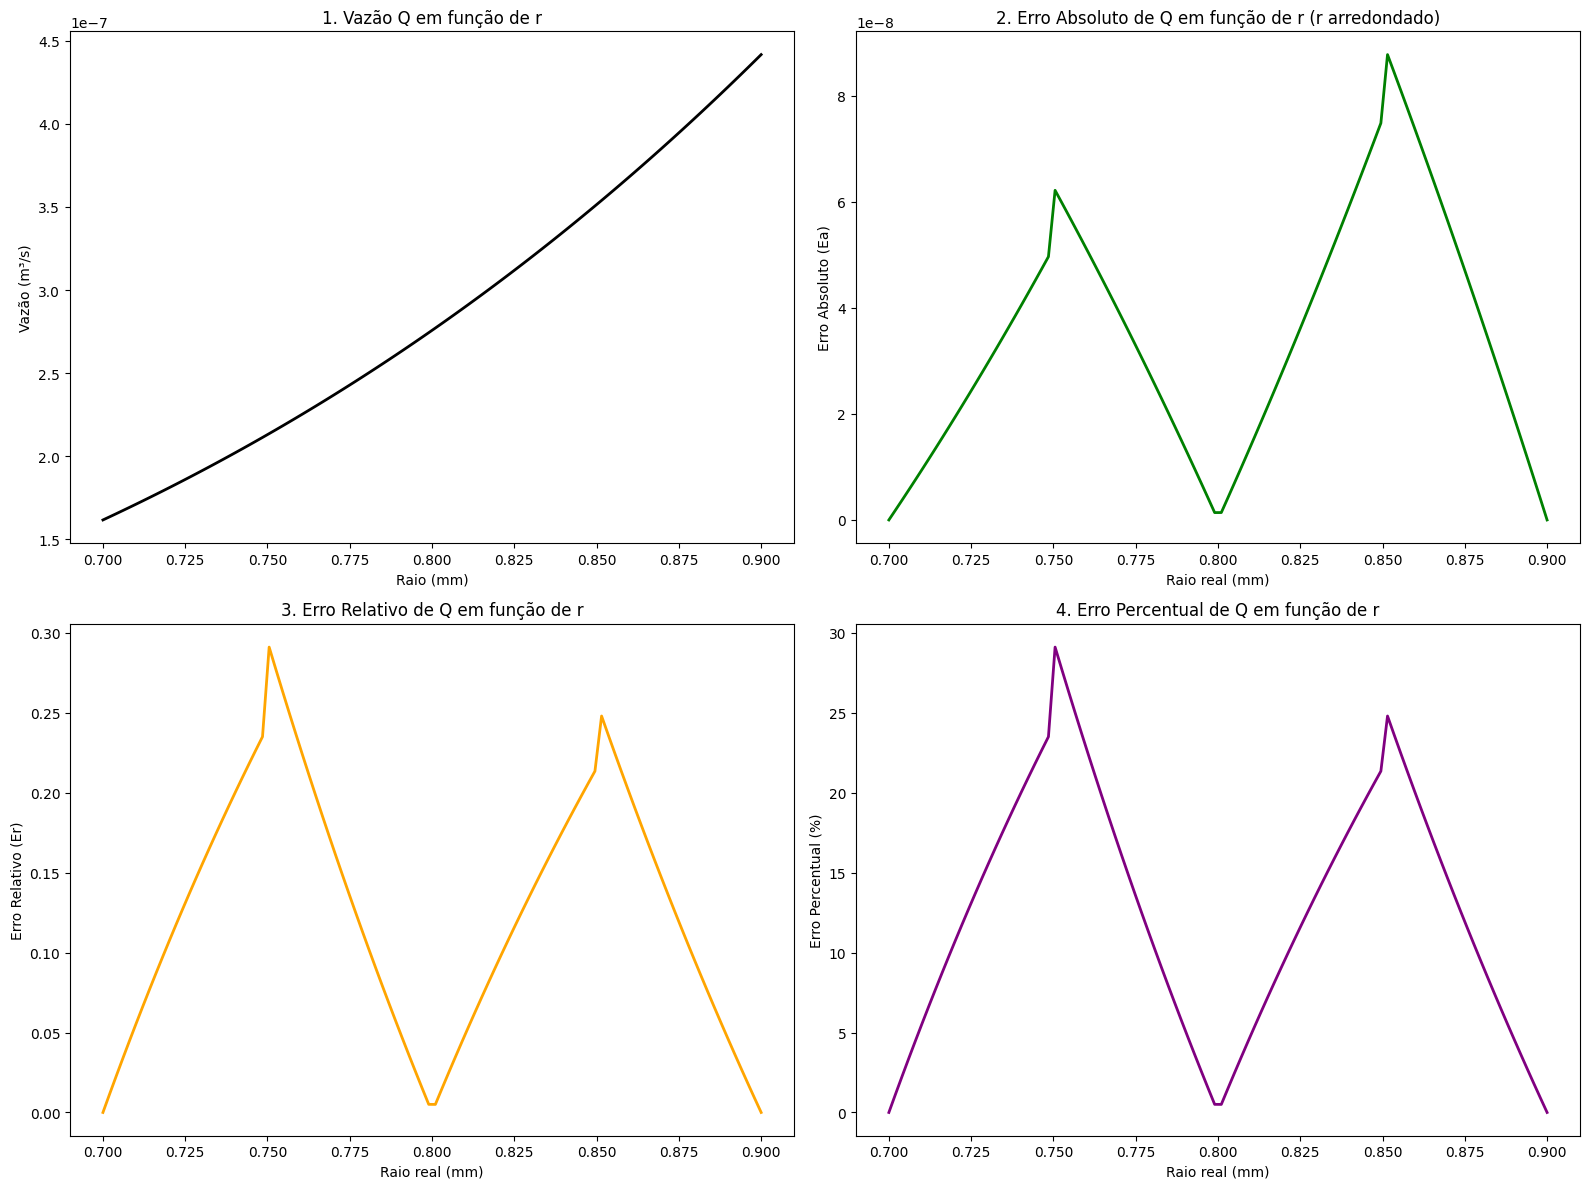

In [30]:
# C.2 Sensibilidade
# Variando o raio de 0,70 a 0,90 mm
raios_mm = np.linspace(0.70, 0.90, 100)
Q_refs = []
Ea_sens, Er_sens, Ep_sens = [], [], []

for r_val in raios_mm:
    Q_real = hagen_poiseuille(r_val*1e-3, L_ref, mu_ref, dp_ref)

    # Q após arredondar r para 1 casa decimal
    r_arred = round(r_val, 1) * 1e-3
    Q_aprox = hagen_poiseuille(r_arred, L_ref, mu_ref, dp_ref)

    Q_refs.append(Q_real)
    Ea_sens.append(erro_absoluto(Q_real, Q_aprox))
    Er_sens.append(erro_relativo(Q_real, Q_aprox))
    Ep_sens.append(erro_percentual(Q_real, Q_aprox))

# Gráficos da Sensibilidade
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

axs[0, 0].plot(raios_mm, Q_refs, 'k-', linewidth=2)
axs[0, 0].set_title('1. Vazão Q em função de r')
axs[0, 0].set_xlabel('Raio (mm)')
axs[0, 0].set_ylabel('Vazão (m³/s)')

axs[0, 1].plot(raios_mm, Ea_sens, 'g-', linewidth=2)
axs[0, 1].set_title('2. Erro Absoluto de Q em função de r (r arredondado)')
axs[0, 1].set_xlabel('Raio real (mm)')
axs[0, 1].set_ylabel('Erro Absoluto (Ea)')

axs[1, 0].plot(raios_mm, Er_sens, 'orange', linewidth=2)
axs[1, 0].set_title('3. Erro Relativo de Q em função de r')
axs[1, 0].set_xlabel('Raio real (mm)')
axs[1, 0].set_ylabel('Erro Relativo (Er)')

axs[1, 1].plot(raios_mm, Ep_sens, 'purple', linewidth=2)
axs[1, 1].set_title('4. Erro Percentual de Q em função de r')
axs[1, 1].set_xlabel('Raio real (mm)')
axs[1, 1].set_ylabel('Erro Percentual (%)')

plt.tight_layout()
plt.show()



### Explicação da Sensibilidade
**Por que o erro no raio é amplificado na vazão?**

Analisando a equação $Q = \frac{\pi \Delta p}{8 \mu L} r^4$, percebemos que $Q \propto r^4$.
Do ponto de vista do Cálculo Diferencial, o erro propagado obedece à aproximação da diferencial:
$$ dQ pprox rac{dQ}{dr} dr = \left( 4 rac{\pi \Delta p}{8 \mu L} r^3
ight) dr = 4 \left( rac{\pi \Delta p}{8 \mu L} r^4
ight) rac{dr}{r} = 4 Q rac{dr}{r} $$

Rearranjando os termos, obtemos o erro relativo:
$$ rac{dQ}{Q} pprox 4 rac{dr}{r} $$

Isso comprova que **o erro relativo da vazão é aproximadamente quatro vezes o erro relativo do raio.** Como o expoente é quatro, o impacto de uma pequena imprecisão na medição do raio é brutalmente amplificado (multiplicado por 4) no resultado final da vazão.



---
## Parte D – Escoamento em um nanocateter
Nesta escala, observaremos tanto as limitações físicas de modelagem quanto os limites computacionais do ponto flutuante.
Valores nominais: $r = 50 	ext{ nm}, L = 10 \mu	ext{m}, \mu = 3.5 	imes 10^{-3} 	ext{ Pa s}, \Delta p = 5000 	ext{ Pa}$.



<>:32: SyntaxWarning: invalid escape sequence '\D'
<>:33: SyntaxWarning: invalid escape sequence '\D'
<>:35: SyntaxWarning: invalid escape sequence '\D'
<>:40: SyntaxWarning: invalid escape sequence '\D'
<>:44: SyntaxWarning: invalid escape sequence '\D'
<>:48: SyntaxWarning: invalid escape sequence '\D'
<>:57: SyntaxWarning: invalid escape sequence '\D'
<>:59: SyntaxWarning: invalid escape sequence '\D'
<>:32: SyntaxWarning: invalid escape sequence '\D'
<>:33: SyntaxWarning: invalid escape sequence '\D'
<>:35: SyntaxWarning: invalid escape sequence '\D'
<>:40: SyntaxWarning: invalid escape sequence '\D'
<>:44: SyntaxWarning: invalid escape sequence '\D'
<>:48: SyntaxWarning: invalid escape sequence '\D'
<>:57: SyntaxWarning: invalid escape sequence '\D'
<>:59: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_2784/3289530654.py:32: SyntaxWarning: invalid escape sequence '\D'
  axs[0, 0].plot(deltas_r_nm, Q_minus, 'b-', label='$Q(r - \Delta r)$')
/tmp/ipykernel_2784/3289530654

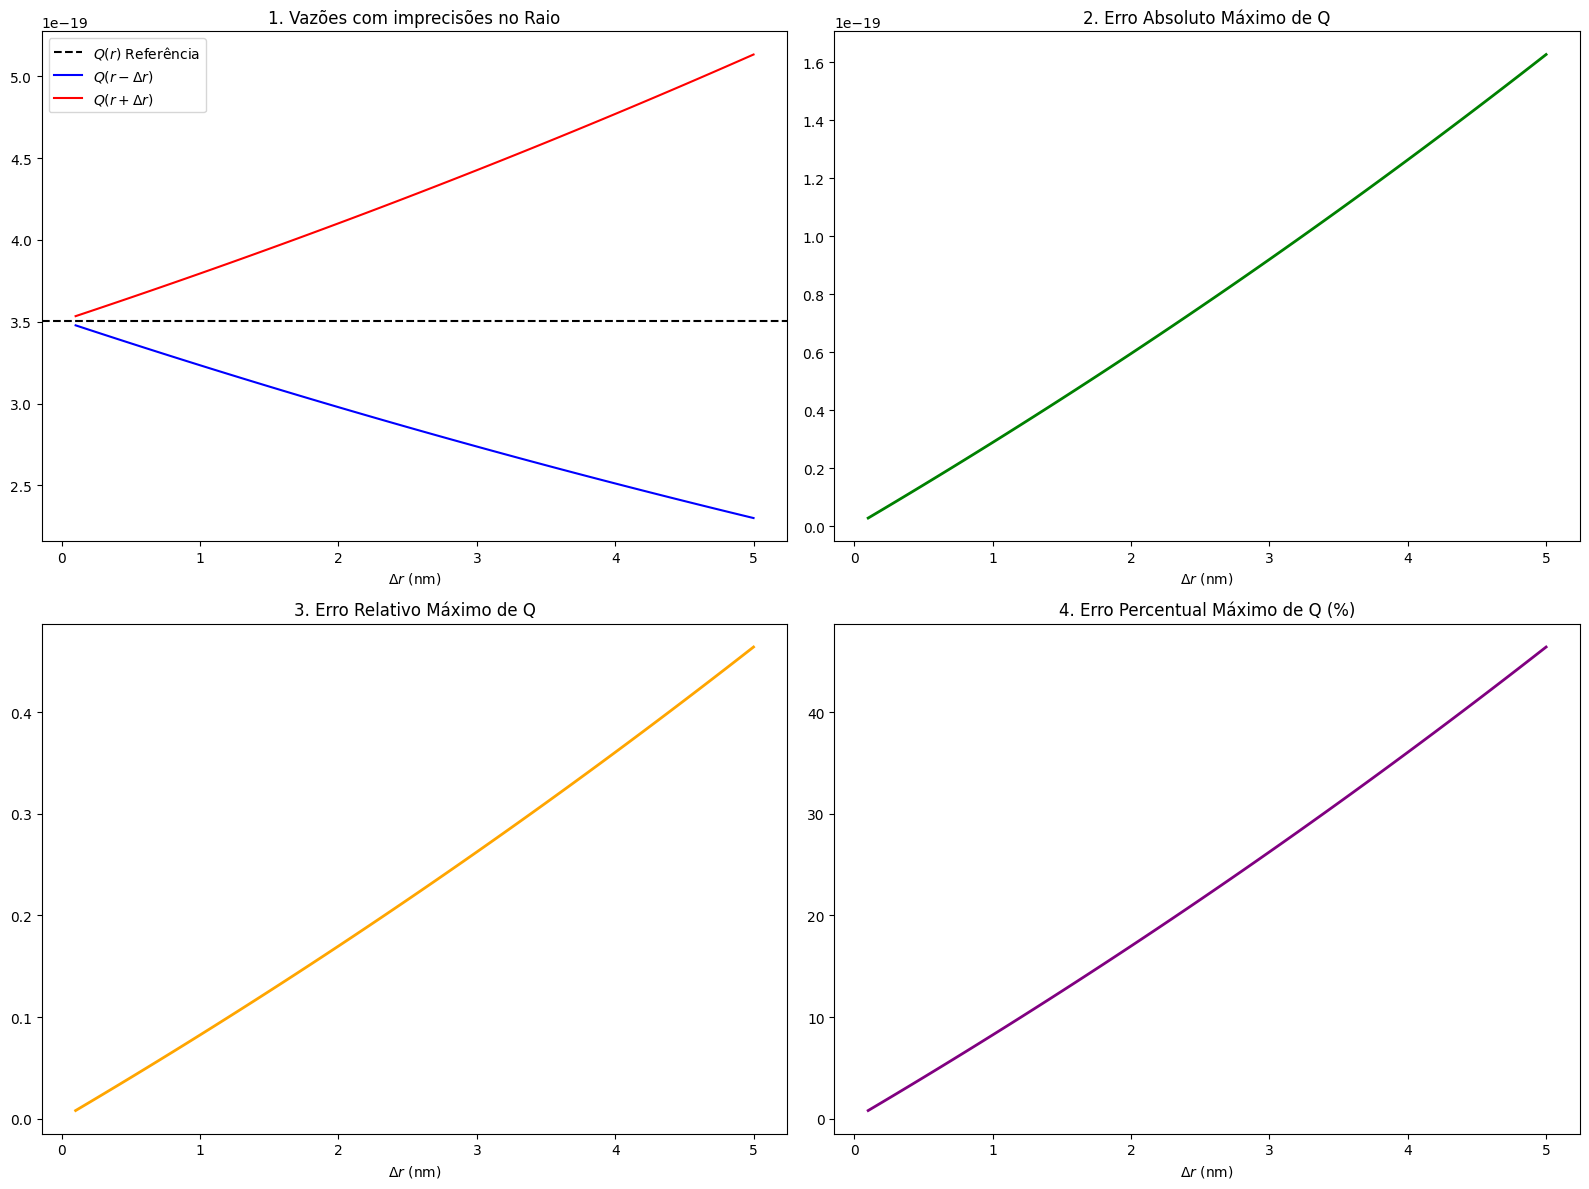

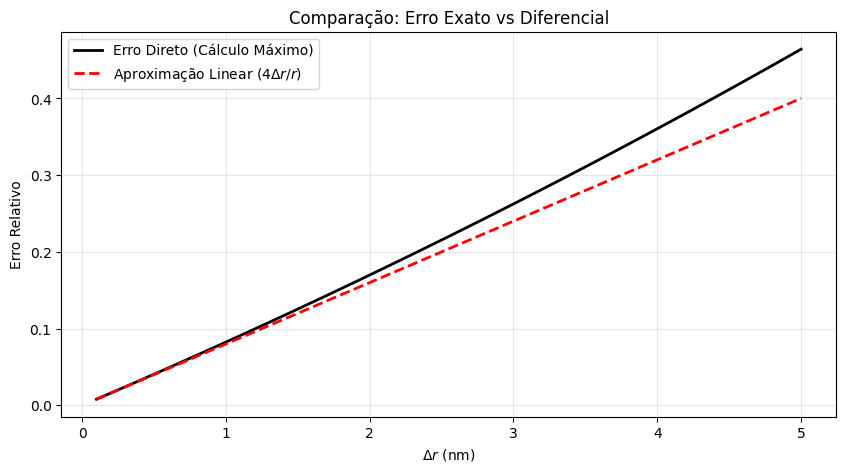

In [31]:
r_nano = 50e-9
L_nano = 10e-6
mu_nano = 3.5e-3
dp_nano = 5000

Q_nano_ref = hagen_poiseuille(r_nano, L_nano, mu_nano, dp_nano)

# D.1 Erro Geométrico
deltas_r_nm = np.arange(0.1, 5.1, 0.1)
Q_minus, Q_plus, Ea_maxs, Er_maxs, Ep_maxs = [], [], [], [], []

for dr in deltas_r_nm:
    dr_m = dr * 1e-9
    Qm = hagen_poiseuille(r_nano - dr_m, L_nano, mu_nano, dp_nano)
    Qp = hagen_poiseuille(r_nano + dr_m, L_nano, mu_nano, dp_nano)

    Q_minus.append(Qm)
    Q_plus.append(Qp)

    # Calcula os erros comparados à vazão real (Q_nano_ref) e pega o pior caso (máximo)
    Ea_m = erro_absoluto(Q_nano_ref, Qm)
    Ea_p = erro_absoluto(Q_nano_ref, Qp)
    Ea_max = max(Ea_m, Ea_p)

    Ea_maxs.append(Ea_max)
    Er_maxs.append(Ea_max / Q_nano_ref)
    Ep_maxs.append(Ea_max * 100 / Q_nano_ref)

fig, axs = plt.subplots(2, 2, figsize=(16, 12))

axs[0, 0].axhline(Q_nano_ref, color='k', linestyle='--', label='$Q(r)$ Referência')
axs[0, 0].plot(deltas_r_nm, Q_minus, 'b-', label='$Q(r - \Delta r)$')
axs[0, 0].plot(deltas_r_nm, Q_plus, 'r-', label='$Q(r + \Delta r)$')
axs[0, 0].set_title('1. Vazões com imprecisões no Raio')
axs[0, 0].set_xlabel('$\Delta r$ (nm)')
axs[0, 0].legend()

axs[0, 1].plot(deltas_r_nm, Ea_maxs, 'g-', linewidth=2)
axs[0, 1].set_title('2. Erro Absoluto Máximo de Q')
axs[0, 1].set_xlabel('$\Delta r$ (nm)')

axs[1, 0].plot(deltas_r_nm, Er_maxs, 'orange', linewidth=2)
axs[1, 0].set_title('3. Erro Relativo Máximo de Q')
axs[1, 0].set_xlabel('$\Delta r$ (nm)')

axs[1, 1].plot(deltas_r_nm, Ep_maxs, 'purple', linewidth=2)
axs[1, 1].set_title('4. Erro Percentual Máximo de Q (%)')
axs[1, 1].set_xlabel('$\Delta r$ (nm)')

plt.tight_layout()
plt.show()

# Comparação linear: Erro direto vs 4*(dr/r)
erro_aprox_linear = 4 * (deltas_r_nm * 1e-9 / r_nano)
plt.figure(figsize=(10, 5))
plt.plot(deltas_r_nm, Er_maxs, 'k-', linewidth=2, label='Erro Direto (Cálculo Máximo)')
plt.plot(deltas_r_nm, erro_aprox_linear, 'r--', linewidth=2, label='Aproximação Linear ($4 \Delta r / r$)')
plt.title('Comparação: Erro Exato vs Diferencial')
plt.xlabel('$\Delta r$ (nm)')
plt.ylabel('Erro Relativo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



In [32]:
# D.2 Precisão Computacional

print("==== ANÁLISE DE PRECISÃO (float32 vs float64) ====")

# Variáveis em Float64
r64, dp64, mu64, L64, pi64 = [np.float64(x) for x in [r_nano, dp_nano, mu_nano, L_nano, np.pi]]
r4_64 = r64**4
Q64 = (pi64 * r4_64 * dp64) / (np.float64(8) * mu64 * L64)

# Variáveis em Float32
r32, dp32, mu32, L32, pi32 = [np.float32(x) for x in [r_nano, dp_nano, mu_nano, L_nano, np.pi]]
r4_32 = r32**4
Q32 = (pi32 * r4_32 * dp32) / (np.float32(8) * mu32 * L32)

print(f"FLOAT64:")
print(f"  r^4 = {r4_64:e}")
print(f"  Q   = {Q64:e}")
print(f"  Eps = {np.finfo(np.float64).eps:e}")

print(f"\nFLOAT32:")
print(f"  r^4 = {r4_32:e}")
print(f"  Q   = {Q32:e}")
print(f"  Eps = {np.finfo(np.float32).eps:e}")

print(f"\nDiferença Absoluta entre float64 e float32: {np.abs(Q64 - Q32):e}")
print(f"Diferença Relativa entre float64 e float32: {np.abs(Q64 - Q32) / Q64:e}")

print("\n==== PERDA DE SIGNIFICÂNCIA POR CANCELAMENTO ====")
# Avaliando pequenas variações dr/r
print(f"{'dr/r':<10} | {'δ1 (Q_diff/Q)':<15} | {'δ2 (Taylor approx)':<18} | {'Diferença (|δ1 - δ2|)':<20}")
print("-" * 75)
fatores_dr = [1e-1, 1e-3, 1e-5, 1e-7, 1e-9, 1e-11, 1e-13, 1e-15, 1e-17]

for f in fatores_dr:
    dr = f * r64
    Q_dr = (pi64 * (r64 + dr)**4 * dp64) / (np.float64(8) * mu64 * L64)

    # Delta 1: Pode sofrer cancelamento catastrófico ao subtrair números muito próximos
    delta_1 = (Q_dr - Q64) / Q64

    # Delta 2: Manipulação algébrica robusta: (1 + dr/r)^4 - 1
    delta_2 = (1 + f)**4 - 1

    diff = np.abs(delta_1 - delta_2)
    print(f"{f:<10.1e} | {delta_1:<15.6e} | {delta_2:<18.6e} | {diff:<20.6e}")



==== ANÁLISE DE PRECISÃO (float32 vs float64) ====
FLOAT64:
  r^4 = 6.250000e-30
  Q   = 3.506242e-19
  Eps = 2.220446e-16

FLOAT32:
  r^4 = 6.250000e-30
  Q   = 3.506242e-19
  Eps = 1.192093e-07

Diferença Absoluta entre float64 e float32: 5.228628e-26
Diferença Relativa entre float64 e float32: 1.491234e-07

==== PERDA DE SIGNIFICÂNCIA POR CANCELAMENTO ====
dr/r       | δ1 (Q_diff/Q)   | δ2 (Taylor approx) | Diferença (|δ1 - δ2|)
---------------------------------------------------------------------------
1.0e-01    | 4.641000e-01    | 4.641000e-01       | 8.326673e-16        
1.0e-03    | 4.006004e-03    | 4.006004e-03       | 2.237793e-16        
1.0e-05    | 4.000060e-05    | 4.000060e-05       | 5.011657e-16        
1.0e-07    | 4.000001e-07    | 4.000001e-07       | 4.612785e-16        
1.0e-09    | 4.000000e-09    | 4.000000e-09       | 6.414137e-16        
1.0e-11    | 3.999984e-11    | 4.000000e-11       | 1.643339e-16        
1.0e-13    | 4.002923e-13    | 3.996803e-13       

### D.3 Fenômeno Físico

**Por que a redução da escala aumenta a razão superfície/volume e torna os efeitos viscosos mais importantes?**

A área superficial interna de um tubo cilíndrico (onde ocorrem as interações viscosas com a parede) é dada por $A = 2\pi rL$, e o seu volume é dado por $V = \pi r^2 L$. A razão entre a área e o volume é $rac{A}{V} = rac{2}{r}$. Notavelmente, essa relação demonstra que quando o raio $r$ diminui drasticamente até a escala nanométrica ($r 	o 0$), a razão $rac{A}{V} 	o \infty$. O volume de fluido cai numa proporção muito mais rápida ($r^2$) do que a superfície de contato ($r^1$). Isso significa que, no escoamento macroscópico, o atrito de parede afeta relativamente pouco a "massa" central do fluido. Em nanoescala, quase a totalidade do volume de fluido está sob extrema influência atrativa e atritiva das paredes. As forças viscosas e intermoleculares começam a dominar por completo o escoamento, em sobreposição aos efeitos inerciais.

**Por fim:** O fato do computador devolver vazões precisas até a 15ª casa decimal sob a modelagem de Hagen-Poiseuille prova **precisão aritmética**, mas não confere **validade física**. A física macroscópica de meios contínuos assume que o fluido é um *continuum* sem "buracos"; em nanocateteres, a dimensão do canal começa a se aproximar do diâmetro das próprias moléculas da água e de fenômenos atômicos de parede (camada de *slip*, pontes de hidrogênio). O modelo falha. "Precisão aritmética" é a exatidão com a qual resolvemos uma conta, enquanto "validade do modelo" descreve se essa conta traduz com sucesso a natureza subjacente.



---
## Parte E – Síntese Visual

Construiremos um Quadro Único de Resultados (.PNG), condensando gráficos e conclusões críticas das etapas acima, servindo como um dashboard explicativo.



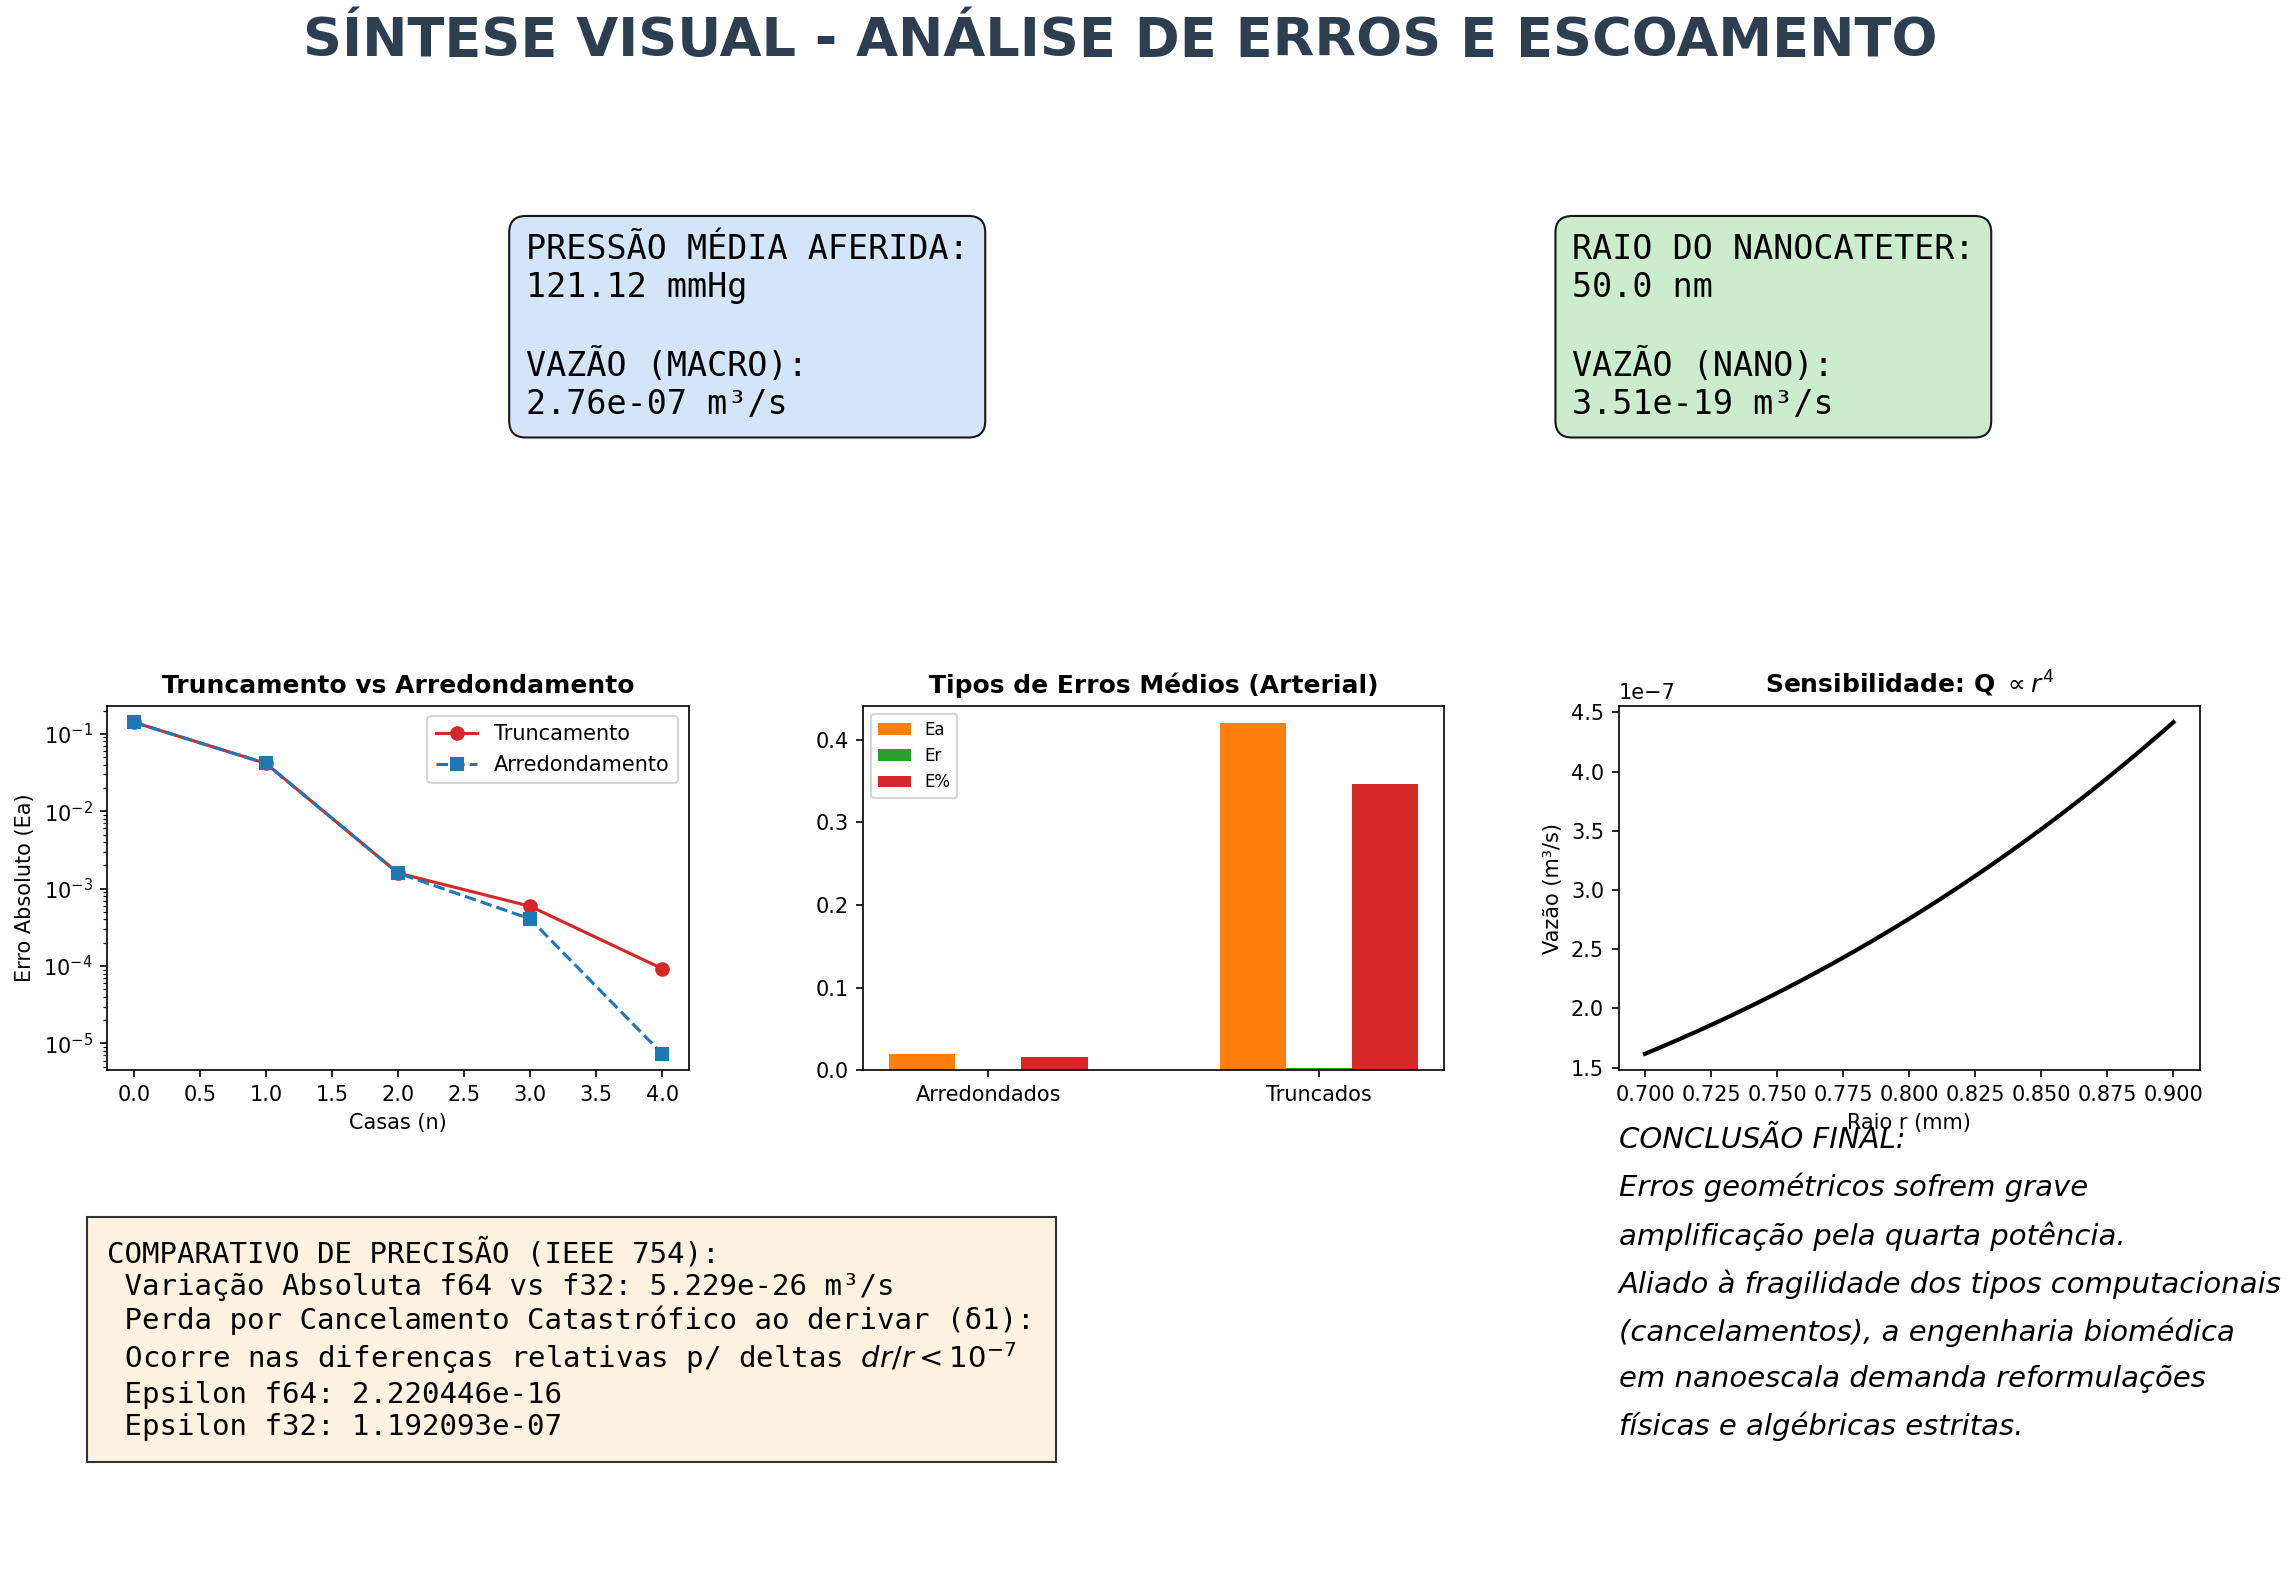

In [33]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('SÍNTESE VISUAL - ANÁLISE DE ERROS E ESCOAMENTO', fontsize=26, weight='bold', color='#2c3e50')
gs = fig.add_gridspec(3, 3, wspace=0.3, hspace=0.4)

# 1. Cartões de valores base
ax0 = fig.add_subplot(gs[0, :]); ax0.axis('off')
texto_macro = f"PRESSÃO MÉDIA AFERIDA:\n{np.mean(medidas_originais):.2f} mmHg\n\nVAZÃO (MACRO):\n{Q_ref:.2e} m³/s"
texto_nano  = f"RAIO DO NANOCATETER:\n{r_nano * 1e9:.1f} nm\n\nVAZÃO (NANO):\n{Q_nano_ref:.2e} m³/s"
ax0.text(0.2, 0.4, texto_macro, fontsize=16, family='monospace', bbox=dict(facecolor='#d0e1f9', alpha=0.9, pad=15, boxstyle='round,pad=0.5'))
ax0.text(0.7, 0.4, texto_nano, fontsize=16, family='monospace', bbox=dict(facecolor='#c6ecc8', alpha=0.9, pad=15, boxstyle='round,pad=0.5'))

# 2. Comparação trunc x arred
ax1 = fig.add_subplot(gs[1, 0])
trunc_A = df_A[(df_A['Valor (x)'] == x_vals[0]) & (df_A['Método']=='Truncamento')]
arred_A = df_A[(df_A['Valor (x)'] == x_vals[0]) & (df_A['Método']=='Arredondamento')]
ax1.plot(trunc_A['Casas (n)'], trunc_A['Ea'], 'o-', label='Truncamento', color='#d62728')
ax1.plot(arred_A['Casas (n)'], arred_A['Ea'], 's--', label='Arredondamento', color='#1f77b4')
ax1.set_yscale('log'); ax1.set_title('Truncamento vs Arredondamento', weight='bold')
ax1.set_xlabel('Casas (n)'); ax1.set_ylabel('Erro Absoluto (Ea)')
ax1.legend()

# 3. Os três tipos de erro (Média P. Arterial)
ax2 = fig.add_subplot(gs[1, 1])
largura = 0.2
idx = np.arange(2)
ea_p = df_erros_medias['Erro Absoluto (Ea)'].values
er_p = df_erros_medias['Erro Relativo (Er)'].values
ep_p = df_erros_medias['Erro Percentual (E%)'].values
ax2.bar(idx - largura, ea_p, largura, label='Ea', color='#ff7f0e')
ax2.bar(idx, er_p, largura, label='Er', color='#2ca02c')
ax2.bar(idx + largura, ep_p, largura, label='E%', color='#d62728')
ax2.set_xticks(idx)
ax2.set_xticklabels(['Arredondados', 'Truncados'])
ax2.set_title('Tipos de Erros Médios (Arterial)', weight='bold')
ax2.legend(fontsize=8)

# 4. Sensibilidade de Q ao raio
ax3 = fig.add_subplot(gs[1, 2])
ax3.plot(raios_mm, Q_refs, 'k-', linewidth=2)
ax3.set_title('Sensibilidade: Q $\\propto r^4$', weight='bold')
ax3.set_xlabel('Raio r (mm)'); ax3.set_ylabel('Vazão (m³/s)')

# 5. Comparação float32 vs float64
ax4 = fig.add_subplot(gs[2, 0:2]); ax4.axis('off')
txt_float = (
    "COMPARATIVO DE PRECISÃO (IEEE 754):\n"
    f" Variação Absoluta f64 vs f32: {np.abs(Q64-Q32):.3e} m³/s\n"
    f" Perda por Cancelamento Catastrófico ao derivar (δ1):\n"
    f" Ocorre nas diferenças relativas p/ deltas $dr/r < 10^{{-7}}$\n"
    f" Epsilon f64: {np.finfo(np.float64).eps:e}\n"
    f" Epsilon f32: {np.finfo(np.float32).eps:e}"
)
ax4.text(0.0, 0.4, txt_float, fontsize=14, family='monospace', bbox=dict(facecolor='#fef0d9', alpha=0.8, pad=10))

# 6. Conclusão curta
ax5 = fig.add_subplot(gs[2, 2]); ax5.axis('off')
txt_conclusao = (
    "CONCLUSÃO FINAL:\n"
    "Erros geométricos sofrem grave\n"
    "amplificação pela quarta potência.\n"
    "Aliado à fragilidade dos tipos computacionais\n"
    "(cancelamentos), a engenharia biomédica\n"
    "em nanoescala demanda reformulações\n"
    "físicas e algébricas estritas."
)
ax5.text(0.0, 0.4, txt_conclusao, fontsize=14, linespacing=1.8, style='italic')

plt.savefig('quadro_sintese_resultados.png', dpi=150, bbox_inches='tight')
plt.close()
display(Image('quadro_sintese_resultados.png'))

---
## Parte 8 - GIF demonstrativo
Neste bloco iterativo, simularemos o crescimento contínuo do raio de 45 a 55 nm, compilando 40 quadros sequenciais (frames) em um `GIF` fluido, comunicando graficamente a dependência não-linear da vazão frente ao alargamento do nanocateter.



<>:26: SyntaxWarning: invalid escape sequence '\p'
<>:26: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2784/2996934231.py:26: SyntaxWarning: invalid escape sequence '\p'
  ax[1].set_title("Crescimento de Vazão (Função $Q \propto r^4$)", weight='bold')


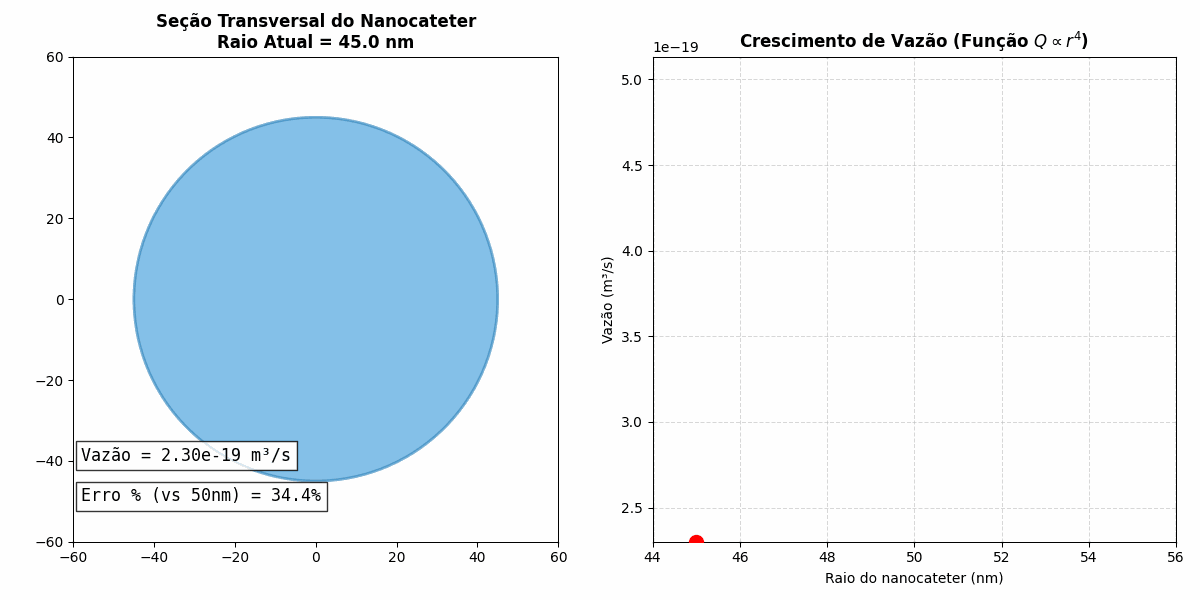

In [34]:
raios_gif = np.linspace(45, 55, 40)
filenames = []

# Criar a pasta temp se precisar (ou só deixar local)
for i, r_nm in enumerate(raios_gif):
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    # Visão da Seção Transversal
    circle = plt.Circle((0, 0), r_nm, color='#3498db', alpha=0.6, ec='#2980b9', lw=2)
    ax[0].add_patch(circle)
    ax[0].set_xlim(-60, 60); ax[0].set_ylim(-60, 60); ax[0].set_aspect('equal')
    ax[0].set_title(f"Seção Transversal do Nanocateter\nRaio Atual = {r_nm:.1f} nm", weight='bold')

    q_atual = hagen_poiseuille(r_nm * 1e-9, L_nano, mu_nano, dp_nano)
    err_pct = erro_percentual(Q_nano_ref, q_atual) if r_nm != 50.0 else 0.0

    ax[0].text(-58, -40, f"Vazão = {q_atual:.2e} m³/s", fontsize=12, family='monospace', bbox=dict(facecolor='white', alpha=0.8))
    ax[0].text(-58, -50, f"Erro % (vs 50nm) = {err_pct:.1f}%", fontsize=12, family='monospace', bbox=dict(facecolor='white', alpha=0.8))

    # Visão da Curva de Vazão
    ax[1].plot(raios_gif[:i+1], [hagen_poiseuille(r*1e-9, L_nano, mu_nano, dp_nano) for r in raios_gif[:i+1]], 'k-', linewidth=3)
    ax[1].plot(r_nm, q_atual, 'ro', markersize=10, zorder=5)
    ax[1].set_xlim(44, 56)
    # y limits fixos para evitar que o gráfico pule:
    ax[1].set_ylim(hagen_poiseuille(45e-9, L_nano, mu_nano, dp_nano), hagen_poiseuille(55e-9, L_nano, mu_nano, dp_nano))
    ax[1].set_title("Crescimento de Vazão (Função $Q \propto r^4$)", weight='bold')
    ax[1].set_xlabel("Raio do nanocateter (nm)")
    ax[1].set_ylabel("Vazão (m³/s)")
    ax[1].grid(True, ls='--', alpha=0.5)

    plt.tight_layout()
    fn = f'frame_{i}.png'
    filenames.append(fn)
    plt.savefig(fn, dpi=100)
    plt.close()

# Compatibilidade de importação do imageio
try:
    import imageio.v2 as imageio_compat
    imread_func = imageio_compat.imread
except ImportError:
    imread_func = imageio.imread

# Compila os quadros em um GIF animado
with imageio.get_writer('nanocateter.gif', mode='I', duration=0.1) as writer:
    for fn in filenames:
        image = imread_func(fn)
        writer.append_data(image)

# Faxina (Limpar frames PNGs intermediários)
for fn in filenames:
    os.remove(fn)

# Mostrar a imagem GIF final
display(Image(filename='nanocateter.gif'))

